----IMPORTING THE MODEL----

In [ ]:
import os
import tensorflow as tf
from google.colab import files

print("🔍 COLD START DIAGNOSTIC")
print("="*50)
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Current directory: {os.getcwd()}")
print("\n📁 Files in directory:")
for f in os.listdir('.'):
    if os.path.isfile(f):
        size = os.path.getsize(f) / 1024
        print(f"   • {f} - {size:.1f} KB")

print("\n" + "="*50)
print("✅ If you see this, Colab is working!")
print("📤 Now upload your model file:")
uploaded = files.upload()

🔍 COLD START DIAGNOSTIC
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Current directory: /content

📁 Files in directory:

✅ If you see this, Colab is working!
📤 Now upload your model file:


Saving quick_deepfake__model.h5 to quick_deepfake__model.h5


-----TESTING-----

📁 Found models: ['quick_deepfake__model.h5']

📂 Loading: quick_deepfake__model.h5
   Size: 37.9 MB
✅ LOADED! Input shape: (None, 128, 128, 3)
📏 Using image size: 128x128

📸 Upload a test image:


Saving real_2705.jpg to real_2705.jpg

🎯 RESULT: REAL 👍
📊 Raw score: 0.9283
💯 Confidence: 85.7%


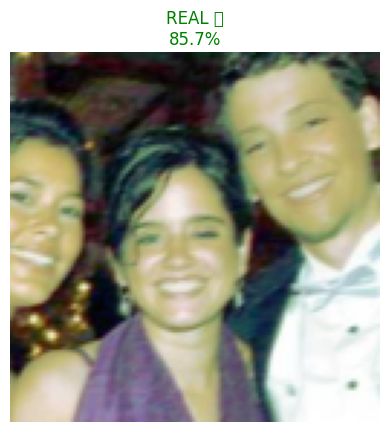

In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image
import matplotlib.pyplot as plt

# Find the model file
model_files = [f for f in os.listdir('.') if f.endswith('.h5')]
print(f"📁 Found models: {model_files}")

if model_files:
    # Use the first one (should be your deepfake.h5)
    model_file = model_files[0]
    print(f"\n📂 Loading: {model_file}")
    print(f"   Size: {os.path.getsize(model_file)/(1024*1024):.1f} MB")

    # Load model
    model = load_model(model_file, compile=False)
    print(f"✅ LOADED! Input shape: {model.input_shape}")

    target_size = model.input_shape[1]
    print(f"📏 Using image size: {target_size}x{target_size}")

    # Now test an image
    print("\n📸 Upload a test image:")
    test_uploaded = files.upload()

    if test_uploaded:
        test_file = list(test_uploaded.keys())[0]

        # Process image
        img = Image.open(test_file)
        img = img.resize((target_size, target_size))
        img_array = np.array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        # Predict
        raw_score = model.predict(img_array, verbose=0)[0][0]

        # Show result
        if raw_score > 0.5:
            result = "REAL 👍"
            conf = (raw_score - 0.5) * 200
            color = 'green'
        else:
            result = "FAKE 🤖"
            conf = (0.5 - raw_score) * 200
            color = 'red'

        print(f"\n🎯 RESULT: {result}")
        print(f"📊 Raw score: {raw_score:.4f}")
        print(f"💯 Confidence: {conf:.1f}%")

        plt.imshow(img)
        plt.title(f"{result}\n{conf:.1f}%", color=color)
        plt.axis('off')
        plt.show()
else:
    print("❌ No .h5 file found! Upload failed?")